# Modules

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# import plotly.graph_objects as go
from plotly.subplots import make_subplots

import plotly.io as pio
pio.renderers.default = "notebook_connected"


# custom libs
import sys
sys.path.append('../../')
from src.preprocessing import df_to_densities, align_densities, align_and_normalize_density
from src.plotting import plot_density_timeseries_3d, style_modes_of_variation, px_select_menu, plot_acf_pacf
from src.transformations import (
                            mLQDT,
                            modes_of_variation,
                            compute_lqd_cut,
                            lqd2dens
                        )
from src.dynamicFPC import K_dFPC

data_path = "../../data/processed/"
doc_path = "../../../densities4risk_doc/Figures/"

In [32]:
# Returns data

returns_path = ''.join([data_path, 'ibovespa_treated.xlsx'])
df_log_returns = pd.read_excel(returns_path, index_col="time")
df_log_returns.head()

,2024-12-02,2024-12-03,2024-12-04,2024-12-05,2024-12-06,2024-12-09,2024-12-10,2024-12-11,2024-12-12,2024-12-13,...,2025-11-14,2025-11-17,2025-11-18,2025-11-19,2025-11-21,2025-11-24,2025-11-25,2025-11-26,2025-11-27,2025-11-28
time,,,,,,,,,,,,,,,,,,,,,
10:05:00,-0.002271,0.003372,0.001716,0.005538,0.000069,0.006429,0.002343,0.001918,-0.007582,-0.000413,...,-0.001522,0.000739,-0.000613,0.000306,-0.002021,-0.000810,0.001557,-0.001565,-0.000193,0.002906
10:10:00,-0.000582,0.002832,-0.000502,0.000739,0.000261,0.001891,0.000775,-0.001172,0.000216,-0.000432,...,0.000360,-0.000105,-0.000159,-0.000362,0.000092,0.001131,0.001170,0.000202,0.000556,0.000475
10:15:00,-0.001997,0.001091,0.000111,-0.000192,0.000407,-0.001392,-0.000477,-0.001526,0.000198,-0.001821,...,0.001121,-0.000284,0.003272,-0.001107,-0.001012,-0.000174,0.001002,0.001815,-0.000168,0.000973
10:20:00,-0.000037,-0.000505,-0.000327,-0.000580,-0.000436,-0.000405,0.001263,0.000676,-0.002667,0.001033,...,0.000449,0.000335,0.000853,0.000981,-0.000057,-0.000096,0.000832,0.001951,0.001060,-0.001004
10:25:00,0.000364,-0.001532,0.000429,-0.000426,-0.000162,-0.000130,0.000060,0.000818,-0.000970,0.000670,...,-0.000871,-0.000559,0.001030,-0.000749,-0.001194,0.001338,0.000128,0.001279,-0.000162,-0.000651


# $L^2$ Simulation

In [33]:
PALETTE = {
    # "WdFPC": "#8338ec",
    "WdFPC": "#c77dff",
    "KdFPC": "#4ae867",  
}

FONT_SIZE = 16
TITLE_SIZE = 18

In [34]:
df_simulation_time = pd.read_excel("../../data/processed/time_simulation_n_2.xlsx")
df_simulation_accuracy = pd.read_excel("../../data/processed/time_simulation_n_2_accuracy.xlsx")

## Computation time

In [35]:
df_simulation_long = df_simulation_time.melt(
    id_vars="n",
    value_vars=["WdFPC", "KdFPC"],
    var_name="Method",
    value_name="Time"
)

# make sure n is categorical
df_simulation_long["n"] = df_simulation_long["n"].astype(str)

In [36]:
# retira valores extremos para gráfico de violino/boxplot
cut_extreme = False

if cut_extreme:
    df_simulation_long = df_simulation_long.copy(deep=True)
    for i in range(15):
        df_simulation_long = df_simulation_long.drop(df_simulation_long.groupby(["n","Method"])["Time"].idxmax().values)

In [37]:
df_simulation_long.rename(columns={"n": "T"}, inplace=True)

### Log-seconds

In [38]:
# # 1. Create the plot using px.strip or px.scatter
# fig = px.strip(
#     df_simulation_long, 
#     x="n", 
#     y="Time", 
#     color="Method",
#     color_discrete_map=PALETTE,
#     # stripmode="overlay" is default, but we'll be explicit:
#     stripmode="overlay" ,
#     width=2000,
#     # height=1000
# )

# # 2. Add transparency and adjust the spread
# fig.update_traces(
#     opacity=0.7,      # Makes them see-through so overlaps appear darker
#     marker=dict(size=8), 
#     jitter=0.7        # Controls how much the dots spread out horizontally
# )

# # 3. Handle the log scale and Top Legend
# fig.update_layout(
#     yaxis_type="log",
#     yaxis_title="Computation time (log-seconds)",
#     xaxis_title="n",
#     template="simple_white",
#     legend=dict(
#         orientation="h",
#         yanchor="bottom",
#         y=1.02,
#         xanchor="center",
#         x=0.5,
#         title_text=""
#     ),
#     yaxis=dict(
#             tickformat=".1e",  # 1 decimal place + exponent (e.g., 1.0e-2)
#             dtick=1,            # Ensures a tick for every power of 10
#             title=dict(font=dict(size=TITLE_SIZE)), # Specific size for 'n' label
#             tickfont=dict(size=FONT_SIZE)          # Specific size for '1.000', '2.000'
#         ),
#     font=dict(size=FONT_SIZE), # Sets a global base size
#     xaxis=dict(
#         title=dict(font=dict(size=TITLE_SIZE)), # Specific size for 'n' label
#         tickfont=dict(size=FONT_SIZE)          # Specific size for '1.000', '2.000'
#     )
# )


# fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')

# fig.write_image(''.join([doc_path, 'sim_n_log_boxplot.png']), scale=2)
# fig.show()

/var/folders/t3/pppk4b013151kb4wpjbj3hvh0000gn/T/ipykernel_90356/2186800506.py:29: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



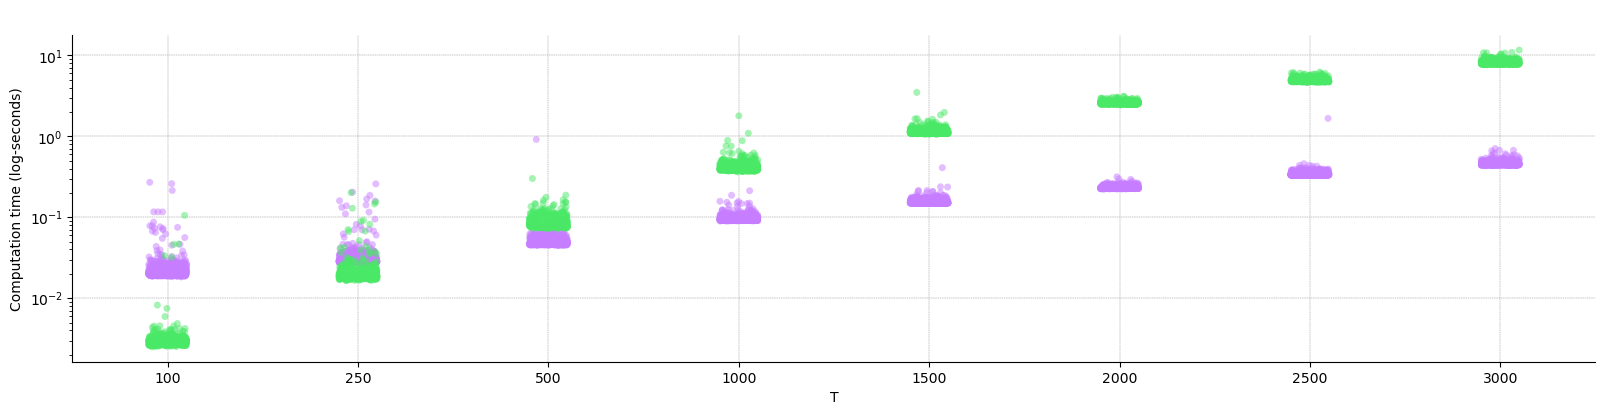

In [39]:
g = sns.catplot(
    data=df_simulation_long,
    x="T",
    y="Time",
    hue="Method",
    height=4,
    aspect=4,
    palette=PALETTE,
    legend=False,
    alpha=0.5,
)

# g.figure.suptitle(
#     "dFPC estimation across samples sizes",
#     fontsize=14,
#     y=1.05
# )
g.set_ylabels("Computation time (log-seconds)")

# Highlight divergence point
# for ax in g.axes.flat:
#     ax.axvspan(
#         1, 2,
#         color="orange",
#         alpha=0.1,
#         zorder=0
#     )

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.10),
    ncol=2,
    frameon=False,
    title=None
)

plt.yscale("log")
plt.grid(color='gray', linestyle='--', linewidth=0.3)

# plt.show()
plt.savefig(''.join([doc_path, 'sim_n_log_boxplot.png']))

## Accuracy

In [40]:
df_simulation_accuracy.rename(columns={"n": "T"}, inplace=True)

/var/folders/t3/pppk4b013151kb4wpjbj3hvh0000gn/T/ipykernel_90356/3950889366.py:37: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



<Figure size 1000x500 with 0 Axes>

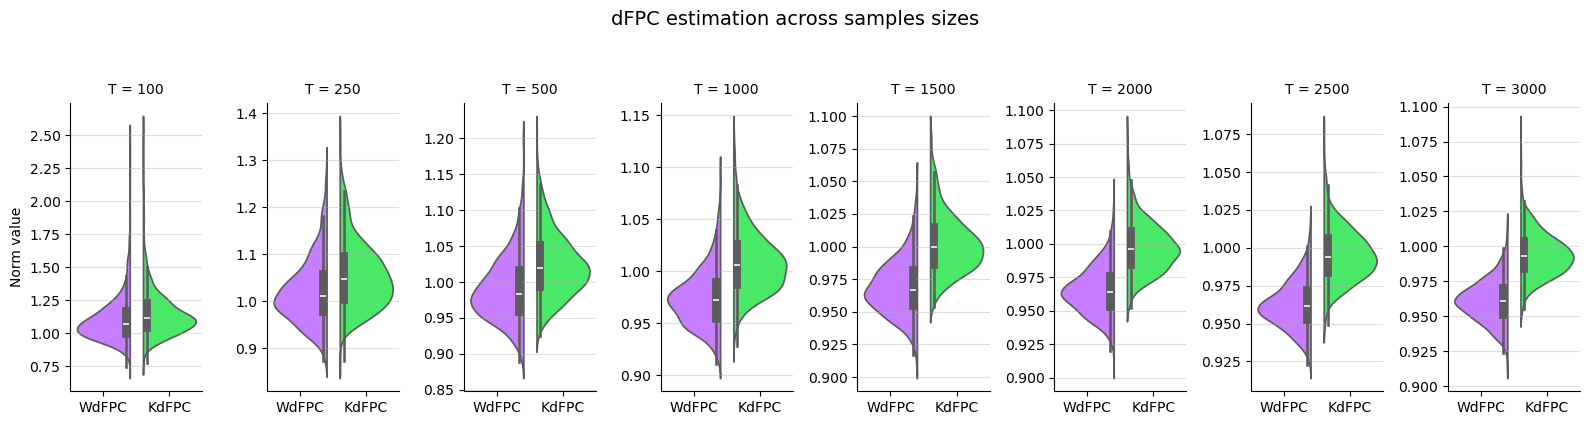

In [41]:
df_accuracy_long_linf = df_simulation_accuracy[df_simulation_accuracy["metric"] == "LINF"]

plt.figure(figsize=(10, 5))

g = sns.catplot(
    data=df_accuracy_long_linf,
    x="Method",
    y="value",
    col="T",
    kind="violin",
    # kind="box",
    hue="Method",
    # kind="violin",
    # inner="quartile",
    # cut=0,
    sharey=False,
    height=4,
    aspect=0.5,
    palette=PALETTE,
    saturation=1,
    split=True,
    legend=False
)


for ax in g.axes.flatten():
    ax.set_xlabel("")   # remove "Method"
    ax.grid(True, axis="y", linestyle="-", alpha=0.4)

g.figure.suptitle(
    "dFPC estimation across samples sizes",
    fontsize=14,
    y=1.05
)
g.set_ylabels(f"Norm value")

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.10),
    ncol=2,
    frameon=False,
    title=None
)

plt.tight_layout()

plt.savefig(''.join([doc_path, 'sim_n_boxplot_accuracy.png']))

# KDE

In [42]:
HEIGHT_3D_PLOT = 700 

In [43]:
params = {
    "kernel": "t_student", 
    "df": 2, 
    "bandwidth": "scott", 
    "adaptive": True
    }
grid, densities = df_to_densities(
                        df_log_returns, 
                        params,
                        normalize_densities=True
                        )

In [80]:
angles = [0.85, 2.0, 1.0]
distance = 1.5
angles = [angle*distance for angle in angles]
fig = plot_density_timeseries_3d(
    densities,
    # x_range = (-0.0005, 0.0005),
    x_range = (-0.003, 0.003),
    # colorscale="mint",
    colorscale="Purp",
    camera= dict(eye=dict(x=angles[0], y=angles[1], z=angles[2])),
    percentile_cut = [0, 95]
    )

fig.update_layout(
    # width=1500,
    # title="3D Density Time Series",
    scene=dict(
        xaxis_title="Support",
        yaxis_title="",
        zaxis_title="Density",
        xaxis=dict(autorange="reversed"),
        aspectratio=dict(
            x=1.5,
            y=2,   # <-- increase this to stretch along Date
            z=1),
        yaxis=dict(
                    tickangle=30,          # Tilts labels to avoid overlap
                    # font=dict(size=12), 
                    # title=dict(standoff=20) # Pushes the 'Month/Year' title further away
                ),
        ),
    margin=dict(l=0, r=0, b=0, t=0),
    height=HEIGHT_3D_PLOT,
)

fig.update_traces(showscale=False)

fig.write_image(''.join([doc_path, 'densities_over_time_3d.png']),scale=2)
fig.show()

# mLQDT

In [45]:
bovespa_mLQDT = mLQDT(
                    densities,
                    grid
                )
bovespa_mLQDT.densities_to_lqdensities(verbose=False)

bovespa_mLQDT.lqd.index = bovespa_mLQDT.lqd_support
df_lqds = bovespa_mLQDT.lqd.copy()

In [ ]:
angles = [0.85, 2.0, -0.5]
distance = 1.5
angles = [angle*distance for angle in angles]


# 3D VIZ
fig = plot_density_timeseries_3d(
    df_lqds.iloc[50:-50,:],
    x_range = (-0.05, 1.05),
    colorscale="Purp_r",
    camera= dict(eye=dict(x=angles[0], y=angles[1], z=angles[2]),
                 center=dict(x=0, y=0, z=0.5)
                 ),
    percentile_cut= [0,97]
    )

fig.update_layout(
    # title="3D Density Time Series",
    scene=dict(
        xaxis_title="Support",
        yaxis_title="",
        zaxis_title="Log-quantile density",
        xaxis=dict(autorange="reversed"),
        aspectratio=dict(
            x=1.5,
            y=2,   # <-- increase this to stretch along Date
            z=1),
        yaxis=dict(
                    tickangle=30,          # Tilts labels to avoid overlap
                    # font=dict(size=12), 
                    # title=dict(standoff=20) # Pushes the 'Month/Year' title further away
                ),
        ),
    margin=dict(l=0, r=0, b=0, t=0),
    height=HEIGHT_3D_PLOT,
)

fig.update_traces(showscale=False)

fig.write_image(''.join([doc_path, 'lqdensities_over_time_3d.png']),scale=2)
fig.show()

# Modes of variation

In [47]:
# dFPC
dimensions = 2
KdFPC_kwargs = {
    "lag_max": 5,
    "alpha": 0.10,
    "du": 0.05,
    "B": 1000,
    "p": 5,
    # "u": df_lqds_support,
    "select_ncomp": False,
    "dimension": dimensions
}

In [48]:
df_lqds = bovespa_mLQDT.lqd.copy()
df_lqds_support = bovespa_mLQDT.lqd_support.copy()

KdFPC_kwargs.update({"u": df_lqds_support})
KdFPC_model = K_dFPC(df_lqds.values)
KdFPC_model.fit(**KdFPC_kwargs)
k_scores = KdFPC_model.etahat.real.T
df_estimated = pd.DataFrame(KdFPC_model.fitted_values, index=df_lqds_support, columns=df_lqds.columns)

In [49]:
perturbations = [0.00, 0.5, 2, 10]
modes = modes_of_variation(
    df_lqds,
    KdFPC_model.psihat,
    KdFPC_model.thetahat,
    alphas=perturbations
)

In [50]:
# USE AVERAGE C TO GET THE INVERSE OF ALL MODES OF VARIATION
common_c = np.mean(bovespa_mLQDT.c)
common_t0 = bovespa_mLQDT.t[0]
common_dSup = grid.iloc[:,0]

# CREATES DATAFRAME IN LONG FORMAT
df_dens_modes = []
for pc in modes.pc.unique():
    for alpha in modes.alpha.unique():
        mode_of_variation = modes[(modes.pc==pc)&(modes.alpha==alpha)]
        lqd = mode_of_variation.loc[:,"value"]
        cut = compute_lqd_cut(lqd, cut_nan=True)
        dSup_temp, dens_temp = lqd2dens(
                                lqd=lqd.values, 
                                lqdSup=mode_of_variation["index"], 
                                c=common_c, 
                                dSup=common_dSup, 
                                cut=cut,
                                verbose=False
                                )
        df_temp = pd.DataFrame(
            {
            "index": dSup_temp,
            "pc": pc,
            "alpha": alpha,
            "value": dens_temp
            }
        )
        df_dens_modes.append(df_temp)

df_pdf_modes = pd.concat(df_dens_modes)

/Users/vizzotto/Documents/GitHub/densities4risk/reports/img/../../src/transformations.py:496: IntegrationWarning:

The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.



In [51]:
# Put all modes of variation on a common grid
df_pc1 = df_pdf_modes[(df_pdf_modes["pc"] == "PC1") & 
                      (df_pdf_modes["alpha"].isin(["alpha_0.0", "alpha_2_minus", "alpha_2_plus"]))]

df_largest_supp_mode = df_pdf_modes[df_pdf_modes["alpha"].isin(["alpha_2_plus"])]
aligned_pdf_modes = []
for alpha in df_pc1["alpha"].unique():
    df_pdf_modes0 = df_pc1[df_pc1["alpha"] == alpha]
    supp_col, f_col, f_hat_col = align_and_normalize_density(df_largest_supp_mode["index"], df_largest_supp_mode["value"], df_pdf_modes0["index"], df_pdf_modes0["value"])
    df_aligned_pdf_modes0 = pd.DataFrame({
                                        "index": supp_col,
                                        "pc":    df_pdf_modes0["pc"].unique()[0],
                                        "alpha": alpha,
                                        "value": f_hat_col
                                        })
    aligned_pdf_modes.append(pd.DataFrame(df_aligned_pdf_modes0))

df_aligned_pdf_modes = pd.concat(aligned_pdf_modes, axis=0)

# Renames rows for viz
df_aligned_pdf_modes.loc[:, "alpha"] = df_aligned_pdf_modes.loc[:, "alpha"].map({
                                                                                "alpha_0.0": "α = 0 (mean)",
                                                                                "alpha_2_plus": "α = 2",
                                                                                "alpha_2_minus": "α = -2"
                                                                                })

# Remove some data to improve viz of dash style lines
df_aligned_pdf_modes = df_aligned_pdf_modes.iloc[::15, :]

fig = px.line(
    df_aligned_pdf_modes,
    x="index",                
    y="value",
    color="alpha", 
    template="plotly_white",
    # title="$ψ_{1}$",
    width=700
)

# Apply specific styles to each line
# alpha_0.0: Thicker and Black
fig.update_traces(
    patch={"line": {"color": "black", "width": 4, "dash": "solid"}},
    selector={"legendgroup": "α = 0 (mean)"}
)

# alpha_2_plus: Dashed Green
fig.update_traces(
    patch={"line": {"color": "green", "width": 2, "dash": "dash"}},
    selector={"legendgroup": "α = 2"}
)

# alpha_2_minus: Dashed Red
fig.update_traces(
    patch={"line": {"color": "red", "width": 2, "dash": "dash"}},
    selector={"legendgroup": "α = -2"}
)

# Ensure the legend reflects the new styles accurately
fig.update_layout(
    legend_title_text="Perturbations",
    xaxis_title="Support",
    yaxis_title="Density"
)

fig.update_layout(
    xaxis=dict(range=[-0.003, 0.003]),
    yaxis=dict(range=[-50, 1650]),
)

# 1. Add the vertical gray line at x=0
fig.add_vline(
    x=0, 
    line_width=1.5, 
    # line_dash="dot", 
    line_color="gray",
    opacity=0.7
)

fig.update_layout(showlegend=False)

fig.write_image(''.join([doc_path, 'modes_variation_pc1.png']),scale=2)
fig.show()

In [52]:
# Put all modes of variation on a common grid
df_pc1 = df_pdf_modes[(df_pdf_modes["pc"] == "PC2") & 
                      (df_pdf_modes["alpha"].isin(["alpha_0.0", "alpha_10_minus", "alpha_10_plus"]))]
df_largest_supp_mode = df_pdf_modes[df_pdf_modes["alpha"].isin(["alpha_10_plus"])]
aligned_pdf_modes = []
for alpha in df_pc1["alpha"].unique():
    df_pdf_modes0 = df_pc1[df_pc1["alpha"] == alpha]
    supp_col, f_col, f_hat_col = align_and_normalize_density(df_largest_supp_mode["index"], df_largest_supp_mode["value"], df_pdf_modes0["index"], df_pdf_modes0["value"])
    df_aligned_pdf_modes0 = pd.DataFrame({
                                        "index": supp_col,
                                        "pc":    df_pdf_modes0["pc"].unique()[0],
                                        "alpha": alpha,
                                        "value": f_hat_col
                                        })
    aligned_pdf_modes.append(pd.DataFrame(df_aligned_pdf_modes0))
df_aligned_pdf_modes = pd.concat(aligned_pdf_modes, axis=0)
df_aligned_pdf_modes.loc[:, "alpha"] = df_aligned_pdf_modes.loc[:, "alpha"].map({
                                                                                "alpha_0.0": "α = 0 (mean)",
                                                                                "alpha_10_plus": "α = 10",
                                                                                "alpha_10_minus": "α = -10"

                                                                                })

# df_aligned_pdf_modes = df_aligned_pdf_modes.iloc[::10, :]

fig = px.line(
    df_aligned_pdf_modes,
    x="index",                
    y="value",
    color="alpha", 
    template="plotly_white",
    # title="$ψ_{1}$",
    width=700
)

# Apply specific styles to each line
# alpha_0.0: Thicker and Black
fig.update_traces(
    patch={"line": {"color": "black", "width": 4, "dash": "solid"}},
    selector={"legendgroup": "α = 0 (mean)"}
)

# alpha_2_plus: Dashed Green
fig.update_traces(
    patch={"line": {"color": "green", "width": 2, "dash": "dash"}},
    selector={"legendgroup": "α = 10"}
)

# alpha_2_minus: Dashed Red
fig.update_traces(
    patch={"line": {"color": "red", "width": 2, "dash": "dash"}},
    selector={"legendgroup": "α = -10"}
)

# Ensure the legend reflects the new styles accurately
fig.update_layout(
    legend_title_text="Perturbations",
    xaxis_title="Support",
    yaxis_title="Density"
)
# 1. Add the vertical gray line at x=0
fig.add_vline(
    x=0, 
    line_width=1.5, 
    # line_dash="dot", 
    line_color="gray",
    opacity=0.7
)

fig.update_layout(
    xaxis=dict(range=[-0.002, 0.002]),
    yaxis=dict(range=[-50, 1100]),
)

fig.update_layout(
    xaxis=dict(
        tickformat=".4f",      # Forces 1 decimal place (e.g., 2.0)
        hoverformat=".4f",     # Keeps high precision when hovering
        exponentformat="none", # STOPS the 'mu' (micro) or 'k' (kilo) prefixes
        showexponent="none"    # Redundant but safe for older Plotly versions
    ),
    yaxis=dict(
        tickformat="d"         # Standard integer for the density values
    )
)

fig.update_layout(showlegend=False)

fig.write_image(''.join([doc_path, 'modes_variation_pc2.png']),scale=2)
fig.show()

# Serial correlation for $\eta$

In [53]:
scores = pd.DataFrame(KdFPC_model.etahat.T, index=df_lqds.columns, columns=[f"$η_{i}$" for i in range(1, KdFPC_model.etahat.T.shape[1]+1)])

fig = px.line(
    scores, 
    # title=f"dFPC scores",
    template='plotly_white',
    width=1000,
    height=300
    )
# px_select_menu(fig)
fig.update_layout(xaxis_title="Date", yaxis_title="")

fig.update_layout(
    legend_title_text=None,
    legend=dict(
        orientation="h",      # horizontal legend
        yanchor="bottom",
        y=1.02,               # slightly above the plot
        xanchor="center",
        x=0.5                 # centered
    )
)

fig.write_image(''.join([doc_path, 'etahat_ts.png']),scale=2)
fig.show()

In [54]:
# # CORRELATION AT T
# corr_matrix = scores.corr(method='pearson').mask(np.eye(len(scores.columns),dtype=bool))
# pair = corr_matrix.stack().idxmax()
# value = corr_matrix.loc[pair[0], pair[1]]
# value_text = f"({pair[0].replace('$','')}, {pair[1].replace('$','')})"

# # VIZ
# fig = px.scatter_matrix(
#     scores,
#     dimensions=[i for i in scores.columns],
#     title=f"Pairwise η_d | max: {value:.4} {value_text}",
#     opacity=0.5,
#     height=1000
# )
# fig.show()

In [55]:
## CORRELATION FOR LAGGED VALUES
# px.scatter(
#     scores.iloc[:,0], scores.iloc[:,0].shift(1),
#     template='plotly_white'
#     )

In [56]:
df_for_dependence = scores.iloc[:,:2]
for d in df_for_dependence.columns:
#     title = f"Correlation analysis"
    fig = plot_acf_pacf(
            scores.loc[:,d], 
        #     title=title,
            nlags=42
            )
    fig.update_layout(template='plotly_white')

    fig.write_image(''.join([doc_path, f'p_acf_eta_{d.replace("$","")}.png']),scale=2)
    fig.show()

## Realized volatility

In [57]:
realized_volatility = pd.read_excel("../../data/processed/ibovespa_realized_volatility.xlsx", index_col="date").loc[:, "realized_volatility"]

In [58]:
# t vs t-1
# fig = px.scatter(
#     x=realized_volatility.shift(1),
#     y=realized_volatility, 
#     title="$(\hat{\zeta}_{t-1}, \hat{\zeta}_t)$",
#     trendline="ols"
#     )

# fig.update_layout(
#     template="plotly_white", 
#     title_x=0.5,
#     xaxis_title=None,
#     yaxis_title=None
#     )
# fig.update_traces(
#     line=dict(color="black", dash="dash"),
#     selector=dict(mode="lines")
# )
# fig.update_traces(
#     marker=dict(color="#c77dff"),
#     selector=dict(mode="markers")
# )
# fig.show()

In [59]:
# vol vs eta
# fig = px.scatter(
#     x=scores.iloc[:,0],
#     y=realized_volatility, 
#     title="$(\hat{\zeta}_{t-1}, \hat{\zeta}_t)$",
#     trendline="ols"
#     )

# fig.update_layout(
#     template="plotly_white", 
#     title_x=0.5,
#     xaxis_title=None,
#     yaxis_title=None
#     )
# fig.update_traces(
#     line=dict(color="black", dash="dash"),
#     selector=dict(mode="lines")
# )
# fig.update_traces(
#     marker=dict(color="#c77dff"),
#     selector=dict(mode="markers")
# )
# fig.show()

In [75]:
# subplots eta1 vs rv
fig1 = px.scatter(
    x=scores.iloc[:, 0],
    y=realized_volatility,
    trendline="ols"
)

fig2 = px.scatter(
    x=scores.iloc[:, 0].shift(1),
    y=realized_volatility,
    trendline="ols"
)

fig = make_subplots(
    rows=1,
    cols=2,
    # subplot_titles=(
    #     r"$\left(\hat{\eta}_{t,1}, \widehat{\zeta}_t\right)$",
    #     r"$\left(\hat{\eta}_{t-1,1}, \widehat{\zeta}_t\right)$"
    # ),
    horizontal_spacing=0.12
)

# Add traces from fig1
for trace in fig1.data:
    fig.add_trace(trace, row=1, col=1)

# Add traces from fig2
for trace in fig2.data:
    fig.add_trace(trace, row=1, col=2)

# Style updates
fig.update_traces(
    line=dict(color="black", dash="dash"),
    selector=dict(mode="lines")
)

fig.update_traces(
    marker=dict(color="#c77dff"),
    selector=dict(mode="markers")
)

fig.update_layout(
    template="plotly_white",
    showlegend=True,
    height=300,
    width=500,
    margin=dict(t=80),
)

# fig.update_xaxes(title=None)
# fig.update_yaxes(title=None)
# Left subplot (η_t,1 vs ζ_t)
fig.update_xaxes(
    title_text=r"$\hat{\eta}_{t,1}$",
    row=1, col=1
)

fig.update_yaxes(
    title_text=r"$\widehat{\zeta}_{t}$",
    row=1, col=1
)

# Right subplot (η_{t-1,1} vs ζ_t)
fig.update_xaxes(
    title_text=r"$\hat{\eta}_{t-1,1}$",
    row=1, col=2
)

# fig.update_yaxes(
#     title_text=r"$\widehat{\zeta}_{t}$",
#     row=1, col=2
# )

fig.update_layout(
    margin=dict(t=80, b=60, l=60, r=20)
)
fig.write_image(''.join([doc_path, f'scatter_rv_eta1.png']),scale=2)
fig.show()